<div style="float: right;">
  <a href="../de/bias_evaluation.html" style="margin-left: 10px;">Deutsch</a>
  <a href="../en/bias_evaluation.html">English</a>
</div>

# 12. Evaluating Bias Impact

Now comes the critical part: comparing how the biased models perform, especially for the underrepresented group (females).

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load and prepare data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
                'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
                'hours_per_week', 'native_country', 'income']
adult_data = pd.read_csv(url, names=column_names, skipinitialspace=True, na_values='?')
adult_data = adult_data.dropna()
adult_data['target'] = (adult_data['income'] == '>50K').astype(int)
adult_data['sex'] = (adult_data['sex'] == 'Male').astype(int)

categorical_cols = ['workclass', 'marital_status', 'occupation', 'relationship', 'race']
for col in categorical_cols:
    le = LabelEncoder()
    adult_data[col] = le.fit_transform(adult_data[col])

feature_cols = ['age', 'workclass', 'education_num', 'marital_status',
                'occupation', 'relationship', 'race', 'sex',
                'capital_gain', 'capital_loss', 'hours_per_week']
X = adult_data[feature_cols]
y = adult_data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=adult_data['sex']
)

# Create biased sample
def create_biased_sample(X, y, sex_col='sex', female_ratio=0.1):
    female_mask = X[sex_col] == 0
    male_mask = X[sex_col] == 1
    X_female, y_female = X[female_mask], y[female_mask]
    X_male, y_male = X[male_mask], y[male_mask]
    n_female_keep = max(1, int(len(X_female) * female_ratio))
    female_indices = np.random.choice(len(X_female), n_female_keep, replace=False)
    X_biased = pd.concat([X_female.iloc[female_indices], X_male])
    y_biased = pd.concat([y_female.iloc[female_indices], y_male])
    return X_biased, y_biased

X_train_biased, y_train_biased = create_biased_sample(X_train, y_train, female_ratio=0.1)

# Train all models
scaler_baseline = StandardScaler()
X_train_scaled = scaler_baseline.fit_transform(X_train)
X_test_scaled_baseline = scaler_baseline.transform(X_test)

scaler_biased = StandardScaler()
X_train_biased_scaled = scaler_biased.fit_transform(X_train_biased)
X_test_scaled_biased = scaler_biased.transform(X_test)

lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr_baseline = lr_baseline.predict(X_test_scaled_baseline)

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_baseline.fit(X_train_scaled, y_train)
y_pred_rf_baseline = rf_baseline.predict(X_test_scaled_baseline)

lr_biased = LogisticRegression(random_state=42, max_iter=1000)
lr_biased.fit(X_train_biased_scaled, y_train_biased)
y_pred_lr_biased = lr_biased.predict(X_test_scaled_biased)

rf_biased = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_biased.fit(X_train_biased_scaled, y_train_biased)
y_pred_rf_biased = rf_biased.predict(X_test_scaled_biased)

print("All models trained and ready for evaluation!")

All models trained and ready for evaluation!


## Overall Performance Comparison

In [2]:
print("=" * 70)
print("OVERALL PERFORMANCE COMPARISON")
print("=" * 70)

print("\nLogistic Regression:")
print(f"  Baseline Accuracy: {accuracy_score(y_test, y_pred_lr_baseline):.3f}")
print(f"  Biased Accuracy:   {accuracy_score(y_test, y_pred_lr_biased):.3f}")

print("\nRandom Forest:")
print(f"  Baseline Accuracy: {accuracy_score(y_test, y_pred_rf_baseline):.3f}")
print(f"  Biased Accuracy:   {accuracy_score(y_test, y_pred_rf_biased):.3f}")

OVERALL PERFORMANCE COMPARISON

Logistic Regression:
  Baseline Accuracy: 0.825
  Biased Accuracy:   0.831

Random Forest:
  Baseline Accuracy: 0.850
  Biased Accuracy:   0.851


## Performance by Demographic Group

In [3]:
def comprehensive_group_evaluation(X_test, y_test, predictions_dict, group_col='sex'):
    """Compare multiple models' performance by group."""
    X_test_reset = X_test.reset_index(drop=True)
    y_test_reset = y_test.reset_index(drop=True)
    results = []

    for group_val in sorted(X_test_reset[group_col].unique()):
        mask = X_test_reset[group_col] == group_val
        group_y_test = y_test_reset[mask]
        group_label = 'Female' if group_val == 0 else 'Male'

        for model_name, y_pred in predictions_dict.items():
            group_y_pred = y_pred[mask]
            acc = accuracy_score(group_y_test, group_y_pred)
            results.append({
                'Group': group_label,
                'Model': model_name,
                'Accuracy': acc,
                'Count': mask.sum()
            })

    return pd.DataFrame(results)

predictions = {
    'LR Baseline': y_pred_lr_baseline,
    'LR Biased': y_pred_lr_biased,
    'RF Baseline': y_pred_rf_baseline,
    'RF Biased': y_pred_rf_biased
}

results_df = comprehensive_group_evaluation(X_test, y_test, predictions)

print("\n" + "=" * 70)
print("PERFORMANCE BY SEX")
print("=" * 70)

pivot_results = results_df.pivot(index='Group', columns='Model', values='Accuracy')
pivot_results = pivot_results[['LR Baseline', 'LR Biased', 'RF Baseline', 'RF Biased']]
print("\nAccuracy by Group:")
print(pivot_results.round(3).to_string())


PERFORMANCE BY SEX

Accuracy by Group:
Model   LR Baseline  LR Biased  RF Baseline  RF Biased
Group                                                 
Female        0.899      0.890        0.917      0.915
Male          0.789      0.803        0.818      0.820


## Performance Drop Analysis

In [4]:
print("\n" + "-" * 70)
print("PERFORMANCE DROP DUE TO BIAS")
print("-" * 70)

for group in ['Female', 'Male']:
    group_data = results_df[results_df['Group'] == group]
    lr_baseline_acc = group_data[group_data['Model'] == 'LR Baseline']['Accuracy'].values[0]
    lr_biased_acc = group_data[group_data['Model'] == 'LR Biased']['Accuracy'].values[0]
    rf_baseline_acc = group_data[group_data['Model'] == 'RF Baseline']['Accuracy'].values[0]
    rf_biased_acc = group_data[group_data['Model'] == 'RF Biased']['Accuracy'].values[0]

    print(f"\n{group}:")
    print(f"  Logistic Regression: {lr_baseline_acc:.3f} -> {lr_biased_acc:.3f} (change: {lr_biased_acc - lr_baseline_acc:+.3f})")
    print(f"  Random Forest:       {rf_baseline_acc:.3f} -> {rf_biased_acc:.3f} (change: {rf_biased_acc - rf_baseline_acc:+.3f})")


----------------------------------------------------------------------
PERFORMANCE DROP DUE TO BIAS
----------------------------------------------------------------------

Female:
  Logistic Regression: 0.899 -> 0.890 (change: -0.009)
  Random Forest:       0.917 -> 0.915 (change: -0.002)

Male:
  Logistic Regression: 0.789 -> 0.803 (change: +0.014)
  Random Forest:       0.818 -> 0.820 (change: +0.002)


## Visualizing the Performance Gap

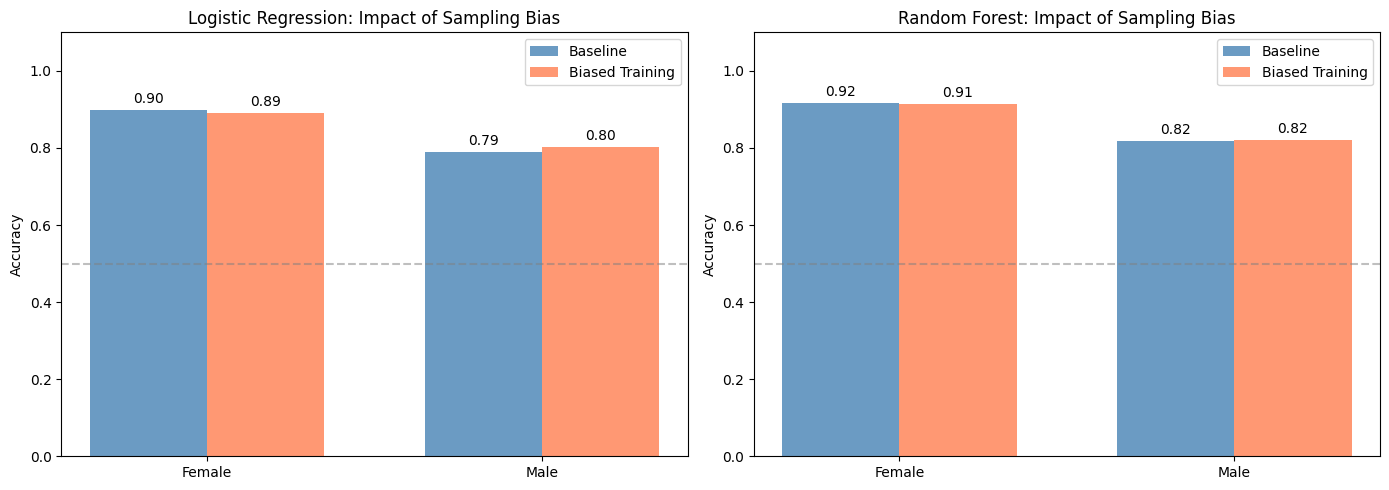

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression comparison
lr_data = results_df[results_df['Model'].str.contains('LR')]
x = np.arange(2)
width = 0.35

baseline_accs = [lr_data[(lr_data['Group'] == 'Female') & (lr_data['Model'] == 'LR Baseline')]['Accuracy'].values[0],
                 lr_data[(lr_data['Group'] == 'Male') & (lr_data['Model'] == 'LR Baseline')]['Accuracy'].values[0]]
biased_accs = [lr_data[(lr_data['Group'] == 'Female') & (lr_data['Model'] == 'LR Biased')]['Accuracy'].values[0],
               lr_data[(lr_data['Group'] == 'Male') & (lr_data['Model'] == 'LR Biased')]['Accuracy'].values[0]]

bars1 = axes[0].bar(x - width/2, baseline_accs, width, label='Baseline', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, biased_accs, width, label='Biased Training', color='coral', alpha=0.8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Logistic Regression: Impact of Sampling Bias')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Female', 'Male'])
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

for bar in bars1 + bars2:
    height = bar.get_height()
    axes[0].annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

# Random Forest comparison
rf_data = results_df[results_df['Model'].str.contains('RF')]

baseline_accs_rf = [rf_data[(rf_data['Group'] == 'Female') & (rf_data['Model'] == 'RF Baseline')]['Accuracy'].values[0],
                    rf_data[(rf_data['Group'] == 'Male') & (rf_data['Model'] == 'RF Baseline')]['Accuracy'].values[0]]
biased_accs_rf = [rf_data[(rf_data['Group'] == 'Female') & (rf_data['Model'] == 'RF Biased')]['Accuracy'].values[0],
                  rf_data[(rf_data['Group'] == 'Male') & (rf_data['Model'] == 'RF Biased')]['Accuracy'].values[0]]

bars3 = axes[1].bar(x - width/2, baseline_accs_rf, width, label='Baseline', color='steelblue', alpha=0.8)
bars4 = axes[1].bar(x + width/2, biased_accs_rf, width, label='Biased Training', color='coral', alpha=0.8)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Random Forest: Impact of Sampling Bias')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Female', 'Male'])
axes[1].legend()
axes[1].set_ylim(0, 1.1)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

for bar in bars3 + bars4:
    height = bar.get_height()
    axes[1].annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Confusion Matrices for Female Individuals

Let's examine the confusion matrices to understand the types of errors:

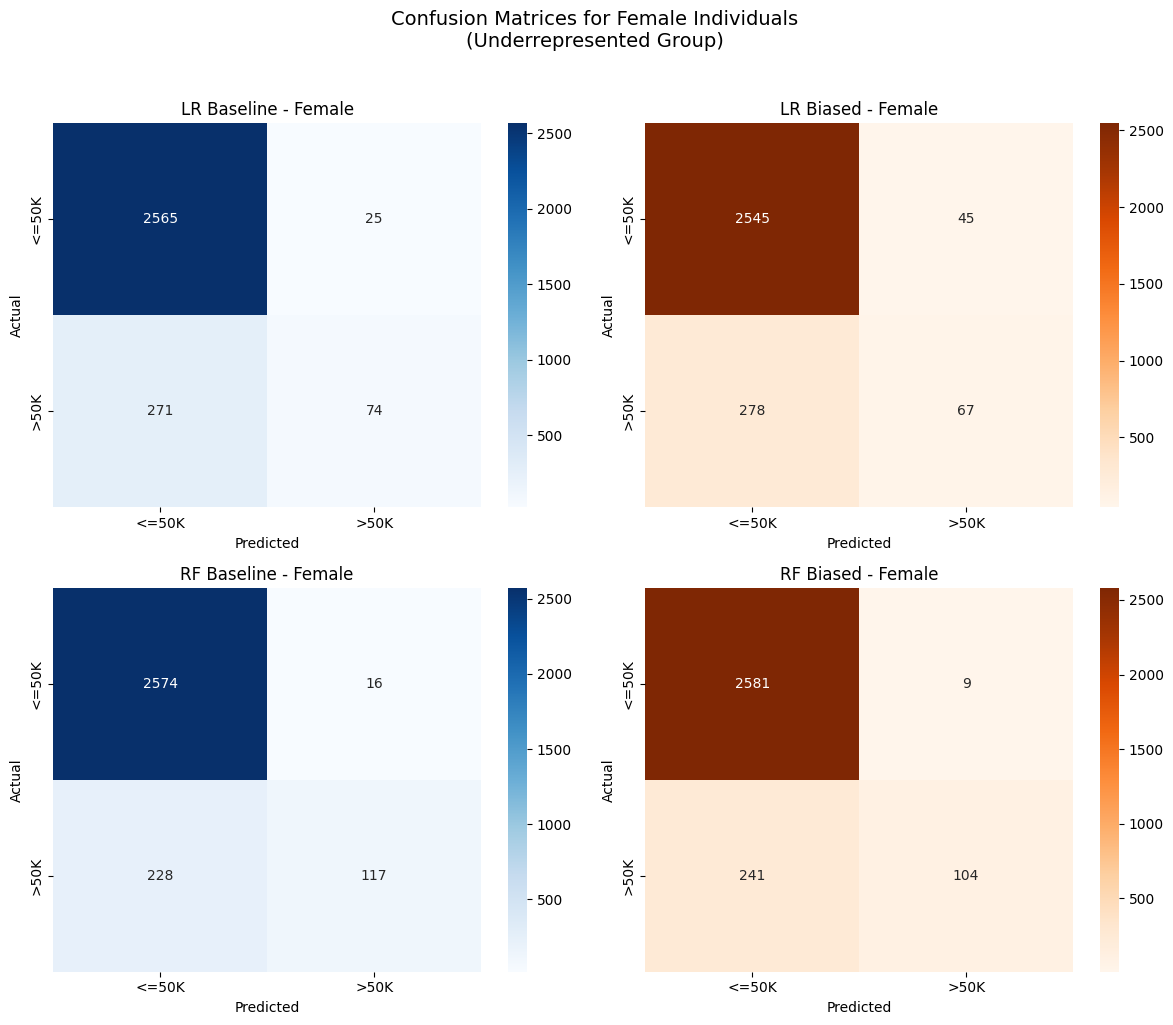

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Get female test data
female_mask = X_test.reset_index(drop=True)['sex'] == 0
y_test_female = y_test.reset_index(drop=True)[female_mask]

# LR Baseline - Female
cm_lr_baseline_female = confusion_matrix(y_test_female, y_pred_lr_baseline[female_mask])
sns.heatmap(cm_lr_baseline_female, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[0, 0].set_title('LR Baseline - Female')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# LR Biased - Female
cm_lr_biased_female = confusion_matrix(y_test_female, y_pred_lr_biased[female_mask])
sns.heatmap(cm_lr_biased_female, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[0, 1].set_title('LR Biased - Female')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# RF Baseline - Female
cm_rf_baseline_female = confusion_matrix(y_test_female, y_pred_rf_baseline[female_mask])
sns.heatmap(cm_rf_baseline_female, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[1, 0].set_title('RF Baseline - Female')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# RF Biased - Female
cm_rf_biased_female = confusion_matrix(y_test_female, y_pred_rf_biased[female_mask])
sns.heatmap(cm_rf_biased_female, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 1],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[1, 1].set_title('RF Biased - Female')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.suptitle('Confusion Matrices for Female Individuals\n(Underrepresented Group)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Fairness Metrics

Let's calculate common fairness metrics to quantify the bias:

In [7]:
def calculate_fairness_metrics(y_test, y_pred, sensitive_attr):
    """Calculate fairness metrics across groups."""
    metrics = {}

    for group_val in sorted(sensitive_attr.unique()):
        mask = sensitive_attr == group_val
        group_y_test = y_test[mask]
        group_y_pred = y_pred[mask]

        tp = ((group_y_pred == 1) & (group_y_test == 1)).sum()
        fn = ((group_y_pred == 0) & (group_y_test == 1)).sum()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0

        fp = ((group_y_pred == 1) & (group_y_test == 0)).sum()
        tn = ((group_y_pred == 0) & (group_y_test == 0)).sum()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        ppr = group_y_pred.mean()

        group_label = 'Female' if group_val == 0 else 'Male'
        metrics[group_label] = {
            'True Positive Rate': tpr,
            'False Positive Rate': fpr,
            'Positive Prediction Rate': ppr
        }

    return pd.DataFrame(metrics).T

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

print("=" * 70)
print("FAIRNESS METRICS")
print("=" * 70)

print("\nLogistic Regression - Baseline:")
print(calculate_fairness_metrics(y_test_reset, y_pred_lr_baseline, X_test_reset['sex']).round(3))

print("\nLogistic Regression - Biased:")
print(calculate_fairness_metrics(y_test_reset, y_pred_lr_biased, X_test_reset['sex']).round(3))

print("\nRandom Forest - Baseline:")
print(calculate_fairness_metrics(y_test_reset, y_pred_rf_baseline, X_test_reset['sex']).round(3))

print("\nRandom Forest - Biased:")
print(calculate_fairness_metrics(y_test_reset, y_pred_rf_biased, X_test_reset['sex']).round(3))

FAIRNESS METRICS

Logistic Regression - Baseline:
        True Positive Rate  False Positive Rate  Positive Prediction Rate
Female               0.214                0.010                     0.034
Male                 0.515                0.086                     0.221

Logistic Regression - Biased:
        True Positive Rate  False Positive Rate  Positive Prediction Rate
Female               0.194                0.017                     0.038
Male                 0.569                0.090                     0.240

Random Forest - Baseline:
        True Positive Rate  False Positive Rate  Positive Prediction Rate
Female               0.339                0.006                     0.045
Male                 0.563                0.065                     0.222

Random Forest - Biased:
        True Positive Rate  False Positive Rate  Positive Prediction Rate
Female               0.301                0.003                     0.039
Male                 0.563                0.062      

## Key Findings

Based on our experiments, we observed:

1. **Overall accuracy can be misleading**: The biased models may show similar overall accuracy, masking significant disparities across groups.

2. **Underrepresented groups suffer most**: Female individuals experienced larger drops in model performance when underrepresented in training data.

3. **Different models, different vulnerabilities**: Logistic Regression and Random Forest respond differently to sampling bias.

4. **Real-world implications**: In hiring and lending decisions, reduced accuracy for women can lead to qualified candidates being unfairly rejected or creditworthy applicants being denied loans.

In the next section, we'll discuss mitigation strategies and ethical considerations.